In [2]:
!pip install --upgrade google-cloud-vision

In [3]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Note: you may need to restart the kernel to use updated packages.


In [4]:
from google.cloud import vision
import io
import os

# Replace with your actual path to the JSON key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/kaggle/input/gcv-json/manifest-canto-466706-v0-1bb68556dfe3.json"

In [5]:
import numpy as np
print(np.__version__)

1.26.4


# Testing Google OCRs

In [6]:
def detect_labels(path):
    client = vision.ImageAnnotatorClient()

    with io.open(path, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    response = client.label_detection(image=image)
    labels = response.label_annotations

    print('Labels:')
    for label in labels:
        print(f"{label.description} (score: {label.score:.2f})")

    if response.error.message:
        raise Exception(f'{response.error.message}')

In [7]:
root = "/kaggle/input/musait/basket/"

In [8]:
# Example usage
detect_labels(root+"negative_022.jpg")

Labels:
Crowd (score: 0.83)
Public event (score: 0.81)
Banner (score: 0.80)
Advertising (score: 0.77)
Logo (score: 0.76)
Smoke (score: 0.74)
Protest (score: 0.68)
High-rise building (score: 0.58)


In [9]:
import sys
!{sys.executable} -m pip install "numpy<2.0" --force-reinstall --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 110.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.5.1 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.3 which is incompatible.
google-cola

Detected text:

obc NEWS SPECIAL REPORT
TWO BOMB EXPLOSIONS AT
THE BOSTON MARATHON
adidas
locale: "en"
description: "obc NEWS SPECIAL REPORT\nTWO BOMB EXPLOSIONS AT\nTHE BOSTON MARATHON\nadidas"
bounding_poly {
  vertices {
    x: 56
    y: 448
  }
  vertices {
    x: 703
    y: 448
  }
  vertices {
    x: 703
    y: 598
  }
  vertices {
    x: 56
    y: 598
  }
}



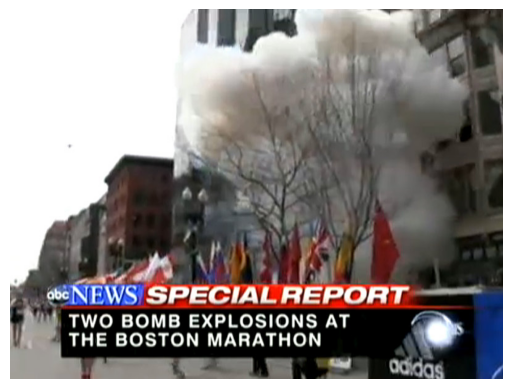

In [10]:
from google.cloud import vision
from PIL import Image
import io
import matplotlib.pyplot as plt

# Initialize the Vision client
client = vision.ImageAnnotatorClient()

# Load your image
image_path = root+"negative_022.jpg"
with io.open(image_path, 'rb') as image_file:
    content = image_file.read()

image = vision.Image(content=content)

# Perform OCR (Text Detection)
response = client.text_detection(image=image)
texts = response.text_annotations

# Display results
if texts:
    print("Detected text:\n")
    print(texts[0].description)
else:
    print("No text detected.")

print(texts[0])

# Optional: Show image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
type(texts[0].bounding_poly.vertices[0])

google.cloud.vision_v1.types.geometry.Vertex

In [12]:
texts

[locale: "en"
description: "obc NEWS SPECIAL REPORT\nTWO BOMB EXPLOSIONS AT\nTHE BOSTON MARATHON\nadidas"
bounding_poly {
  vertices {
    x: 56
    y: 448
  }
  vertices {
    x: 703
    y: 448
  }
  vertices {
    x: 703
    y: 598
  }
  vertices {
    x: 56
    y: 598
  }
}
, description: "obc"
bounding_poly {
  vertices {
    x: 56
    y: 448
  }
  vertices {
    x: 99
    y: 448
  }
  vertices {
    x: 99
    y: 479
  }
  vertices {
    x: 56
    y: 479
  }
}
, description: "NEWS"
bounding_poly {
  vertices {
    x: 99
    y: 448
  }
  vertices {
    x: 208
    y: 448
  }
  vertices {
    x: 208
    y: 479
  }
  vertices {
    x: 99
    y: 479
  }
}
, description: "SPECIAL"
bounding_poly {
  vertices {
    x: 221
    y: 448
  }
  vertices {
    x: 435
    y: 448
  }
  vertices {
    x: 435
    y: 479
  }
  vertices {
    x: 221
    y: 479
  }
}
, description: "REPORT"
bounding_poly {
  vertices {
    x: 440
    y: 448
  }
  vertices {
    x: 646
    y: 448
  }
  vertices {
    x: 

In [13]:
type(content)

bytes

# Google Cloud Vision OCR

In [14]:
!pip install --upgrade opencv-python --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 93.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 120.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: opencv-python━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: opencv-python 4.11.0.862 [numpy]
    Uninstalling opencv-python-4.11.0.86:━━━ 0/2 [numpy]
      Successfully uninstalled opencv-python-4.11.0.86━━━━━━━━━━━━ 1/2 [opencv-python]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]0m [opencv-python]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have n

In [15]:
!pip install pandas==2.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 94.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.5.1 which is incompatible.
ydata-profiling 4.16.1 requires numpy<2.2,>=1.16.0, but you have numpy 2.2.6 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.3 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires requests==2.32.3, but you have requests 2.32.4 which is inco

In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np

In [17]:
def get_gcv_ocr(content):
    client = vision.ImageAnnotatorClient()
    image = vision.Image(content=content)

    # Perform OCR (Text Detection)
    response = client.text_detection(image=image)
    texts = response.text_annotations
    
    # texts[0] contains all info about the entire line of detected text
    # texts[0].description contains the entire line of detected text
    
    return texts


def get_orientation(coordinates):
    A,B,C,D = coordinates[0],coordinates[1],coordinates[2],coordinates[3]
    # A -> Lower left
    # B -> Lower right
    # C -> Upper right
    # D -> Upper left

In [18]:
# root = "/kaggle/input/musait/basket"

In [19]:
print("Number of files =",len(os.listdir(root)))

Number of files = 2875


In [20]:
files = os.listdir(root)
files.sort()

columns = ["filename", "filepath", "text-detected", "OCR", "coordinates", "sentiment"]
ocr = pd.DataFrame(columns=columns)

In [21]:
# ocr.loc[2] = ["fdfs","fsf","fsf","negative"]
ocr

,filename,filepath,text-detected,OCR,coordinates,sentiment


In [22]:
# !pip install tqdm
root

'/kaggle/input/musait/basket/'

In [23]:
# from tqdm import tqdm
# import cv2
count = 0


# for file in tqdm(files, desc="Extracting OCR from files"):
for file in files:
    # filepath = root+"/"+file
    filepath = root+file
    print(filepath)
    with io.open(filepath, 'rb') as image_file:
        content = image_file.read()
    
    texts = get_gcv_ocr(content)

    coordinates = []
    text = ""
    flag = 0 # text detection flag
    if texts:
        # print("Detected text:\n")
        flag = 1
        text = texts[0].description
        bounding_poly = texts[0].bounding_poly
        for vertex in bounding_poly.vertices:
            coordinates.append({"x": vertex.x, "y": vertex.y})

    # if coordinates!=[]:
    #     orientation = get_orientation(coordinates)

    ocr.loc[count] = [file, filepath, flag, text, coordinates, file.split("_")[0]]
    count+=1
    # break

/kaggle/input/musait/basket/negative_001.jpg
/kaggle/input/musait/basket/negative_002.jpg
/kaggle/input/musait/basket/negative_003.jpg
/kaggle/input/musait/basket/negative_004.jpg
/kaggle/input/musait/basket/negative_005.jpg
/kaggle/input/musait/basket/negative_006.jpg
/kaggle/input/musait/basket/negative_007.jpg
/kaggle/input/musait/basket/negative_008.jpg
/kaggle/input/musait/basket/negative_009.jpg
/kaggle/input/musait/basket/negative_010.jpg
/kaggle/input/musait/basket/negative_011.jpg
/kaggle/input/musait/basket/negative_012.jpg
/kaggle/input/musait/basket/negative_013.jpg
/kaggle/input/musait/basket/negative_014.jpg
/kaggle/input/musait/basket/negative_015.jpg
/kaggle/input/musait/basket/negative_016.jpg
/kaggle/input/musait/basket/negative_017.jpg
/kaggle/input/musait/basket/negative_018.jpg
/kaggle/input/musait/basket/negative_019.jpg
/kaggle/input/musait/basket/negative_020.jpg
/kaggle/input/musait/basket/negative_021.jpeg
/kaggle/input/musait/basket/negative_022.jpg
/kaggle/i

In [25]:
ocr

,filename,filepath,text-detected,OCR,coordinates,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket/negative_001.jpg,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",negative
1,negative_002.jpg,/kaggle/input/musait/basket/negative_002.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",negative
2,negative_003.jpg,/kaggle/input/musait/basket/negative_003.jpg,0,,[],negative
3,negative_004.jpg,/kaggle/input/musait/basket/negative_004.jpg,0,,[],negative
4,negative_005.jpg,/kaggle/input/musait/basket/negative_005.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",negative
...,...,...,...,...,...,...
2870,positive_995.jpg,/kaggle/input/musait/basket/positive_995.jpg,1,"66\nJust keep taking\nchances and\nhaving fun,...","[{'x': 129, 'y': 157}, {'x': 587, 'y': 157}, {...",positive
2871,positive_996.jpg,/kaggle/input/musait/basket/positive_996.jpg,1,66\nNever regret anything\nthat made you smile...,"[{'x': 15, 'y': 144}, {'x': 710, 'y': 144}, {'...",positive
2872,positive_997.jpg,/kaggle/input/musait/basket/positive_997.jpg,1,"Click Here\nif you don't\nimagine, nothing\nev...","[{'x': 29, 'y': 32}, {'x': 608, 'y': 32}, {'x'...",positive
2873,positive_998.jpg,/kaggle/input/musait/basket/positive_998.jpg,1,OF COURSE IT'S HARD.\nIT'S SUPPOSED TO BE\nHAR...,"[{'x': 78, 'y': 296}, {'x': 660, 'y': 296}, {'...",positive


In [26]:
ocr.to_csv("gcv-ocr.csv", index=False)

In [27]:
from PIL import Image, ImageDraw

# Example coordinates of bounding box (4 corners)
vertices = ocr.loc[0]['coordinates']

print(root)

/kaggle/input/musait/basket/


In [28]:
vertices

[{'x': 513, 'y': 24},
 {'x': 975, 'y': 24},
 {'x': 975, 'y': 263},
 {'x': 513, 'y': 263}]

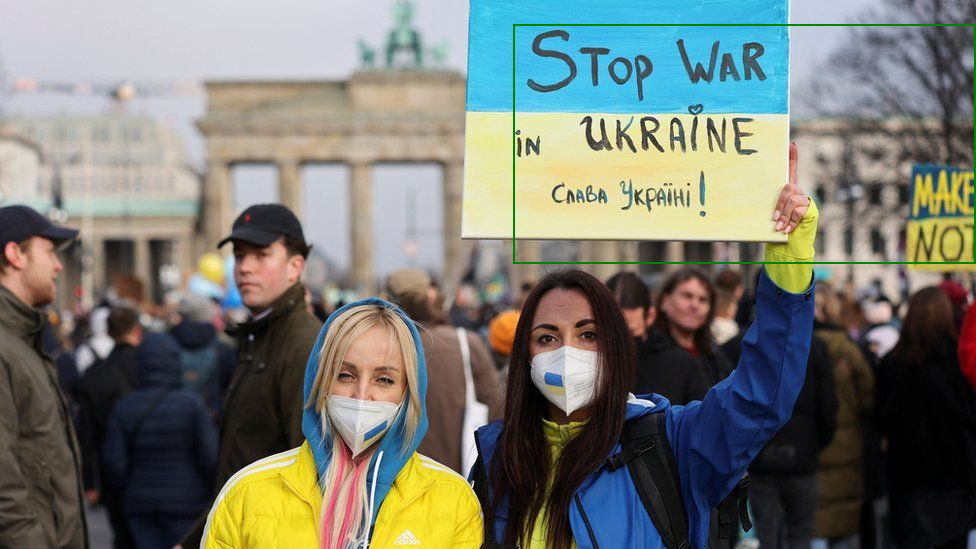

In [29]:
# Load the image
image = Image.open(root+"negative_001.jpg").convert("RGB")
draw = ImageDraw.Draw(image)

# Draw the polygon (connects all points)
polygon = [(v['x'], v['y']) for v in vertices]
draw.polygon(polygon, outline="red", width=2)

# Or draw just the rectangle if the points are axis-aligned
x_coords = [v['x'] for v in vertices]
y_coords = [v['y'] for v in vertices]
xmin, xmax = min(x_coords), max(x_coords)
ymin, ymax = min(y_coords), max(y_coords)
draw.rectangle([xmin, ymin, xmax, ymax], outline="green", width=2)

# Save or display
# image.save("image_with_box.jpg")
from IPython.display import display
display(image)

In [30]:
type(image)

PIL.Image.Image

In [31]:
image.save("negative__001_hf_bddBox.jpg")